In [1]:
%load_ext autoreload
%autoreload 2

# Section 0: 导入、数据库连接与建表

新建 `summary.lod1_valid_eum_blocks` 表，从原汇总表复制全部基础字段与已有指标，
新增EUM相关字段（初始值均为NULL，后续逐步填入）。

In [2]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from dotenv import load_dotenv
from psycopg2.extras import execute_values
from shapely import wkt, MultiPoint, minimum_bounding_circle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import utils_z

warnings.filterwarnings('ignore')

load_dotenv()
conn = utils_z.get_conn(
    os.getenv("DB_NAME"),
    os.getenv("DB_USER"),
    os.getenv("DB_PASSWORD"),
    os.getenv("DB_HOST"),
    os.getenv("DB_PORT")
)
print("数据库连接成功")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('output', exist_ok=True)

数据库连接成功


In [3]:
lod1_cities = [
    "hamburg", "sanfrancisco",
    "amsterdam", "dresden", "berlin", "rotterdam",
    "luxembourg", "chicago", "boston", "washington",
    "newyork", "portland", "tokyo", "sapporo", "osaka", "kanazawa",
    "toronto", "vienna", "winnipeg", "zurich", "bologna",
    "paris", "lyon", "marseille"
]
print(f"共 {len(lod1_cities)} 个城市")

共 24 个城市


In [4]:
# ── 构建城市索引名→全名的映射（从 city_name_map 表读取）──
city_map_rows = utils_z.run_sql(
    "SELECT city_query, city FROM summary.city_name_map;",
    fetch=True, conn=conn
)
CITY_NAME_LOOKUP = {row[0]: row[1] for row in city_map_rows}
print(f"已加载 {len(CITY_NAME_LOOKUP)} 个城市映射")
for city in lod1_cities:
    if city not in CITY_NAME_LOOKUP:
        print(f"  ⚠ {city} 不在 city_name_map 中，跳过")
    else:
        print(f"  {city} -> {CITY_NAME_LOOKUP[city]}")

已加载 33 个城市映射
  hamburg -> Hamburg
  sanfrancisco -> San Francisco
  amsterdam -> Amsterdam
  dresden -> Dresden
  berlin -> Berlin
  rotterdam -> Rotterdam
  luxembourg -> Luxembourg
  chicago -> Chicago
  boston -> Boston
  washington -> Washington D.C.
  newyork -> New York
  portland -> Portland
  tokyo -> Tokyo
  sapporo -> Sapporo
  osaka -> Osaka
  kanazawa -> Kanazawa
  toronto -> Toronto
  vienna -> Vienna
  winnipeg -> Winnipeg
  zurich -> Zurich
  bologna -> Bologna
  paris -> Paris
  lyon -> Lyon
  marseille -> Marseille


In [8]:
# ──────────────────────────────────────────────────────
#  建表 summary.lod1_valid_eum_blocks
#  基础字段 + 全部已有指标 + EUM新增字段
# ──────────────────────────────────────────────────────
utils_z.run_sql("""
    CREATE TABLE IF NOT EXISTS summary.lod1_valid_eum_blocks (
        -- 基础字段
        block_id            VARCHAR NOT NULL PRIMARY KEY,
        city                VARCHAR NOT NULL,
        country             VARCHAR,
        geom                GEOMETRY(Polygon, 4326),
        area_m2             NUMERIC,

        -- === 已有指标（从原表复制） ===
        elongation          NUMERIC,
        compactness         NUMERIC,
        lod1_building_count INTEGER,
        bcr                 NUMERIC,
        convexity           NUMERIC,
        rectangularity      NUMERIC,

        far                 NUMERIC,
        bcd                 NUMERIC,
        osr                 NUMERIC,

        avh                 NUMERIC,
        avh_w               NUMERIC,
        hsd                 NUMERIC,
        hcv                 NUMERIC,
        h_max               NUMERIC,
        h_range             NUMERIC,

        total_volume        NUMERIC,
        avg_volume          NUMERIC,
        avg_footprint       NUMERIC,
        footprint_cv        NUMERIC,

        avg_complexity      NUMERIC,
        avg_rectangularity  NUMERIC,
        avg_convexity       NUMERIC,

        avg_orientation     NUMERIC,
        orientation_entropy NUMERIC,
        avg_nn_distance     NUMERIC,

        -- === EUM 基础变量 ===
        mcc_radius          NUMERIC,   -- 最小外接圆半径（米）
        mcc_area            NUMERIC,   -- 最小外接圆面积（m²）
        mcc_center          GEOMETRY(Point, 4326),   -- 最小外接圆圆心

        -- === 新增中间变量 ===
        ba_std              NUMERIC,   -- 建筑底面积标准差
        bl_ave              NUMERIC,   -- 建筑平均周长
        bl_std              NUMERIC,   -- 建筑周长标准差
        dc                  NUMERIC,   -- 建筑到Block质心的平均距离
        f_block             NUMERIC,   -- Block面积 / MCC面积（块体形状因子）
        rvh                 NUMERIC,   -- Σ(立面面积) / Block面积（立面面积比）

        -- === EUM 归一化指标 ===
        rba_ave             NUMERIC,   -- avg_footprint / mcc_area
        rbl_ave             NUMERIC,   -- bl_ave / (2π × mcc_radius)
        rdc                 NUMERIC,   -- dc / mcc_radius
        rdb_min             NUMERIC    -- avg_nn_distance / mcc_radius
    );
""", conn=conn)
print("summary.lod1_valid_eum_blocks 表创建完成")

In [9]:
# Section 0 import cleanup and reload
utils_z.run_sql("TRUNCATE TABLE summary.lod1_valid_eum_blocks CASCADE;", conn=conn)
print("table cleared")

for city in lod1_cities:
    try:
        sql = f"""
            INSERT INTO summary.lod1_valid_eum_blocks (
                block_id, city, country, geom, area_m2,
                elongation, compactness, lod1_building_count, bcr,
                convexity, rectangularity,
                far, bcd, osr,
                avh, avh_w, hsd, hcv, h_max, h_range,
                total_volume, avg_volume, avg_footprint, footprint_cv,
                avg_complexity, avg_rectangularity, avg_convexity,
                avg_orientation, orientation_entropy, avg_nn_distance
            )
            SELECT
                b.block_id, b.city, b.country, b.geom, b.area_m2,
                b.elongation, b.compactness, b.lod1_building_count, b.bcr,
                b.convexity, b.rectangularity,
                b.far, b.bcd, b.osr,
                b.avh, b.avh_w, b.hsd, b.hcv, b.h_max, b.h_range,
                b.total_volume, b.avg_volume, b.avg_footprint, b.footprint_cv,
                b.avg_complexity, b.avg_rectangularity, b.avg_convexity,
                b.avg_orientation, b.orientation_entropy, b.avg_nn_distance
            FROM summary.lod1_valid_blocks b
            JOIN summary.city_name_map m ON b.city = m.city
            WHERE m.city_query = '{city}';
        """
        utils_z.run_sql(sql, conn=conn)
        print(f"  [{city}] copied")
    except Exception as e:
        conn.rollback()
        print(f"  [{city}] error: {e}")

print("\ncreating indexes...")
utils_z.run_sql("""
    CREATE INDEX IF NOT EXISTS eum_blocks_city_block_idx
    ON summary.lod1_valid_eum_blocks (city, block_id);
""", conn=conn)
utils_z.run_sql("""
    CREATE INDEX IF NOT EXISTS eum_blocks_geom_idx
    ON summary.lod1_valid_eum_blocks USING GIST (geom);
""", conn=conn)
utils_z.run_sql("""
    CREATE INDEX IF NOT EXISTS eum_blocks_mcc_center_idx
    ON summary.lod1_valid_eum_blocks USING GIST (mcc_center);
""", conn=conn)
print("index done")

total = utils_z.run_sql(
    "SELECT COUNT(*) FROM summary.lod1_valid_eum_blocks;",
    fetch=True, conn=conn
)[0][0]
print(f"\nimport complete, total {total} rows")


# Section 1: 计算MCC（最小外接圆）

对每个block，收集所有建筑footprint的顶点作为点集，计算最小外接圆（MCC）。
\
方法：逐城市，从建筑表提取block的建筑几何 → Shapely `minimum_bounding_circle` → 写回半径与面积。

In [10]:
from collections import defaultdict

# ── 检查哪些block已有mcc值，跳过已计算的 ──
existing_mcc = utils_z.run_sql(
    "SELECT COUNT(*) FROM summary.lod1_valid_eum_blocks WHERE mcc_radius IS NOT NULL;",
    fetch=True, conn=conn
)[0][0]
print(f"已有MCC值的block: {existing_mcc}")

if existing_mcc == 0:
    for city in lod1_cities:
        bld_table = f"lod1.{city}_buildings_lod1"
        try:
            # Step 1: 查询每个block的建筑footprint WKT
            rows = utils_z.run_sql(f"""
                SELECT b.block_id, ST_AsText(b.geom_2d)
                FROM {bld_table} b
                WHERE b.block_id IS NOT NULL
                  AND b.geom_2d IS NOT NULL
                  AND ST_IsValid(b.geom_2d) = true;
            """, fetch=True, conn=conn)

            if len(rows) == 0:
                print(f"  [{city}] 无有效建筑，跳过")
                continue

            # Step 2: 按block聚合顶点
            block_points = defaultdict(list)  # block_id -> list of (x, y) tuples
            for block_id, geom_wkt in rows:
                try:
                    poly = wkt.loads(geom_wkt)
                    if poly.is_empty:
                        continue
                    # 取所有外环顶点
                    coords = list(poly.exterior.coords)[:-1]  # 去掉闭合点
                    block_points[block_id].extend(coords)
                except Exception:
                    continue

            # Step 3: 计算每个block的MCC
            mcc_data = []  # [(mcc_radius, mcc_area, center_wkt, block_id), ...]
            for block_id, pts in block_points.items():
                if len(pts) < 3:
                    continue
                multipoint = MultiPoint(pts)
                try:
                    circle = minimum_bounding_circle(multipoint)
                    if circle.is_empty:
                        continue
                    cx, cy = circle.centroid.x, circle.centroid.y
                    radius_deg = circle.length / (2 * math.pi)  # 周长→半径（单位：度）
                    m_per_deg = 111320 * math.cos(math.radians(cy))  # 当前纬度下的米/度
                    radius = radius_deg * m_per_deg  # → 米
                    area_circle = math.pi * radius * radius  # → 平方米
                    center_wkt = f'POINT({cx} {cy})'
                    mcc_data.append((float(radius), float(area_circle), center_wkt, str(block_id)))
                except Exception:
                    continue

            # Step 4: 写回数据库
            if mcc_data:
                with conn.cursor() as cur:
                    execute_values(cur, f"""
                        UPDATE summary.lod1_valid_eum_blocks AS sv
                        SET mcc_radius = v.r,
                            mcc_area   = v.a,
                            mcc_center = ST_GeomFromText(v.center_wkt, 4326)
                        FROM (VALUES %s) AS v(r, a, center_wkt, block_id)
                        WHERE sv.block_id = v.block_id::VARCHAR;
                    """, mcc_data)
                conn.commit()
            print(f"  [{city}] ✓ MCC计算: {len(mcc_data)} blocks / {len(block_points)} 有建筑")
        except Exception as e:
            conn.rollback()
            print(f"  [{city}] ✗ 错误: {e}")

    print("\nMCC计算完成")
else:
    print("MCC已有值，跳过计算")

# ── 统计 ──
mcc_stats = utils_z.run_sql(
    "SELECT COUNT(*) AS total, COUNT(mcc_radius) AS with_mcc FROM summary.lod1_valid_eum_blocks;",
    fetch=True, conn=conn
)[0]
print(f"有MCC值的block: {mcc_stats[1]}/{mcc_stats[0]} ({mcc_stats[1]/mcc_stats[0]*100:.1f}%)")

# Section 2: 计算中间变量

计算ba_std, bl_ave, bl_std, dc, f_block, rvh。\
其中bl_ave/bl_std依赖建筑perimeter聚合，ba_std依赖建筑area聚合，\
dc依赖建筑质心到block质心的距离，f_block和rvh依赖已有字段。

In [11]:
# ──────────────────────────────────────────────────────
#  2a: bl_ave, bl_std, ba_std — 建筑周长与底面积聚合
# ──────────────────────────────────────────────────────
existing = utils_z.run_sql(
    "SELECT COUNT(*) FROM summary.lod1_valid_eum_blocks WHERE bl_ave IS NOT NULL;",
    fetch=True, conn=conn
)[0][0]
print(f"已有bl_ave: {existing}")

if existing == 0:
    for city in lod1_cities:
        bld_table = f"lod1.{city}_buildings_lod1"
        try:
            utils_z.run_sql(f"""
                UPDATE summary.lod1_valid_eum_blocks sv
                SET
                    bl_ave = agg.avg_perimeter,
                    bl_std = agg.stddev_perimeter,
                    ba_std = agg.stddev_area
                FROM (
                    SELECT
                        b.block_id,
                        AVG(b.perimeter)   AS avg_perimeter,
                        STDDEV(b.perimeter) AS stddev_perimeter,
                        STDDEV(b.area)      AS stddev_area
                    FROM {bld_table} b
                    WHERE b.block_id IS NOT NULL
                      AND b.perimeter IS NOT NULL
                      AND b.area IS NOT NULL
                    GROUP BY b.block_id
                ) agg
                WHERE sv.block_id = agg.block_id
                  AND sv.city = '{CITY_NAME_LOOKUP[city]}';
            """, conn=conn)
            print(f"  [{city}] ✓ bl_ave/bl_std/ba_std 完成")
        except Exception as e:
            conn.rollback()
            print(f"  [{city}] ✗ 错误: {e}")
    print("\nbl_ave, bl_std, ba_std 计算完成")
else:
    print("bl_ave已有值，跳过")

In [8]:
# ──────────────────────────────────────────────────
#  2b: dc — 建筑到Block质心的平均距离
#  用建筑geom_2d的质心到block geom的质心的平均距离
# ──────────────────────────────────────────────────
existing = utils_z.run_sql(
    "SELECT COUNT(*) FROM summary.lod1_valid_eum_blocks WHERE dc IS NOT NULL;",
    fetch=True, conn=conn
)[0][0]
print(f"已有dc: {existing}")

if existing == 0:
    for city in lod1_cities:
        bld_table = f"lod1.{city}_buildings_lod1"
        try:
            utils_z.run_sql(f"""
                WITH block_centers AS (
                    SELECT
                        sv.block_id,
                        ST_Centroid(sv.geom)::geography AS block_center
                    FROM summary.lod1_valid_eum_blocks sv
                    WHERE sv.city = '{CITY_NAME_LOOKUP[city]}'
                ),
                building_centers AS (
                    SELECT
                        b.block_id,
                        ST_Centroid(b.geom_2d)::geography AS building_center
                    FROM {bld_table} b
                    WHERE b.block_id IS NOT NULL
                      AND b.geom_2d IS NOT NULL
                      AND ST_IsValid(b.geom_2d) = true
                ),
                dc_agg AS (
                    SELECT
                        bc.block_id,
                        AVG(ST_Distance(bld.building_center, bc.block_center)) AS dc
                    FROM block_centers bc
                    JOIN building_centers bld
                      ON bld.block_id = bc.block_id
                    GROUP BY bc.block_id
                )
                UPDATE summary.lod1_valid_eum_blocks sv
                SET dc = dc_agg.dc
                FROM dc_agg
                WHERE sv.block_id = dc_agg.block_id
                  AND sv.city = '{CITY_NAME_LOOKUP[city]}';
            """, conn=conn)
            print(f"  [{city}] ✓ dc 计算完成")
        except Exception as e:
            conn.rollback()
            print(f"  [{city}] ✗ 错误: {e}")
    print("\ndc 计算完成")
else:
    print("dc已有值，跳过")


In [9]:
# ──────────────────────────────────────────────────────
#  2c: f_block 与 rvh
#  f_block = area_m2 / mcc_area
#  rvh = Σ(perimeter × height) / area_m2  (立面面积近似)
# ──────────────────────────────────────────────────────
utils_z.run_sql("""
    UPDATE summary.lod1_valid_eum_blocks
    SET f_block = CASE
        WHEN mcc_area IS NOT NULL AND mcc_area > 0
        THEN area_m2 / mcc_area
        ELSE NULL
    END;
""", conn=conn)

for city in lod1_cities:
    bld_table = f"lod1.{city}_buildings_lod1"
    try:
        utils_z.run_sql(f"""
            UPDATE summary.lod1_valid_eum_blocks sv
            SET rvh = CASE
                WHEN sv.area_m2 > 0
                THEN agg.total_facade / sv.area_m2
                ELSE NULL
            END
            FROM (
                SELECT
                    b.block_id,
                    SUM(b.perimeter * b.height) AS total_facade
                FROM {bld_table} b
                WHERE b.block_id IS NOT NULL
                  AND b.perimeter IS NOT NULL
                  AND b.height IS NOT NULL
                GROUP BY b.block_id
            ) agg
            WHERE sv.block_id = agg.block_id
              AND sv.city = '{CITY_NAME_LOOKUP[city]}';
        """, conn=conn)
        print(f"  [{city}] ✓ rvh 计算完成")
    except Exception as e:
        conn.rollback()
        print(f"  [{city}] ✗ 错误: {e}")

print("\nf_block + rvh 计算完成")

# Section 3: 计算EUM归一化指标

基于MCC半径/面积，对有尺度依赖的指标做归一化。
\
- rba_ave = avg_footprint / mcc_area
- rbl_ave = bl_ave / (2π × mcc_radius)
- rdc = dc / mcc_radius
- rdb_min = avg_nn_distance / mcc_radius

In [10]:
utils_z.run_sql("""
    UPDATE summary.lod1_valid_eum_blocks
    SET
        rba_ave = CASE
            WHEN mcc_area IS NOT NULL AND mcc_area > 0
            THEN avg_footprint / mcc_area
            ELSE NULL
        END,
        rbl_ave = CASE
            WHEN mcc_radius IS NOT NULL AND mcc_radius > 0
            THEN bl_ave / (2 * PI() * mcc_radius)
            ELSE NULL
        END,
        rdc = CASE
            WHEN mcc_radius IS NOT NULL AND mcc_radius > 0
            THEN dc / mcc_radius
            ELSE NULL
        END,
        rdb_min = CASE
            WHEN mcc_radius IS NOT NULL AND mcc_radius > 0
            THEN avg_nn_distance / mcc_radius
            ELSE NULL
        END;
""", conn=conn)
print("EUM归一化指标计算完成")

# ── 验证 ──
eum_counts = utils_z.run_sql("""
    SELECT
        COUNT(*) AS total,
        COUNT(rba_ave) AS cnt_rba_ave,
        COUNT(rbl_ave) AS cnt_rbl_ave,
        COUNT(rdc) AS cnt_rdc,
        COUNT(rdb_min) AS cnt_rdb_min
    FROM summary.lod1_valid_eum_blocks;
""", fetch=True, conn=conn)[0]
print(f"rba_ave: {eum_counts[1]}/{eum_counts[0]}")
print(f"rbl_ave: {eum_counts[2]}/{eum_counts[0]}")
print(f"rdc:     {eum_counts[3]}/{eum_counts[0]}")
print(f"rdb_min: {eum_counts[4]}/{eum_counts[0]}")

# Section 4: 数据加载与清洗

从EUM表读取指标 + 元数据（city, block_id），\
过滤NULL行，异常值截断。\
\
通过 `CLUSTER_MODE` 切换输入变量集：\
- 'eum_18' → 论文18个EUM变量（7几何 + 11EUM特有），与本notebook聚类实验对应\
- 'all_38' → 全部38个指标（保留的备选方案）

In [5]:
# ═══════════════════════════════════════════════════════
#  手动开关：聚类输入模式
#    'eum_18'  → 论文18个EUM变量（7几何 + 11EUM特有）（默认）
#    'all_38'  → 全部38个指标（保留的备选方案）
# ═══════════════════════════════════════════════════════
CLUSTER_MODE = 'eum_18'

# ── 全部38个指标列 ──
METRIC_COLS_ORIG = [
    # A. 几何属性（5）
    'area_m2', 'elongation', 'compactness', 'convexity', 'rectangularity',
    # B. 密度与数量（5）
    'lod1_building_count', 'bcr', 'far', 'bcd', 'osr',
    # C. 高度（6）
    'avh', 'avh_w', 'hsd', 'hcv', 'h_max', 'h_range',
    # D. 体量与平面（4）
    'total_volume', 'avg_volume', 'avg_footprint', 'footprint_cv',
    # E. 建筑形态（3）
    'avg_complexity', 'avg_rectangularity', 'avg_convexity',
    # F. 朝向与分布（3）
    'avg_orientation', 'orientation_entropy', 'avg_nn_distance',
]

METRIC_COLS_EUM = [
    # G. EUM基础（2）
    'mcc_radius', 'mcc_area',
    # H. 中间变量（4）
    'ba_std', 'bl_ave', 'bl_std', 'dc',
    # I. EUM新指标（6）
    'f_block', 'rvh', 'rba_ave', 'rbl_ave', 'rdc', 'rdb_min',
]

# ── 论文18个EUM变量（7几何 + 11EUM特有）──
EUM18_GEOM = [    # 7个几何变量
    'area_m2',    # A_block
    'mcc_radius', # R_circle
    'mcc_area',   # A_circle
    'f_block',    # F_block
    'rvh',        # RVH
    'bcr',        # RBC
    'avh',        # BH_ave
]
EUM11_SPECIFIC = [  # 11个EUM特有变量
    'hsd',            # BH_std
    'avg_footprint',  # BA_ave
    'ba_std',         # BA_std
    'bl_ave',         # BL_ave
    'bl_std',         # BL_std
    'dc',             # DC
    'avg_nn_distance',# DB_min
    'rba_ave',        # RBA_ave
    'rbl_ave',        # RBL_ave
    'rdc',            # RDC
    'rdb_min',        # RDB_min
]
METRIC_COLS_EUM18 = EUM18_GEOM + EUM11_SPECIFIC

# ── 根据模式选择 ──
if CLUSTER_MODE == 'eum_18':
    METRIC_COLS = METRIC_COLS_EUM18
    mode_label = 'EUM18（7几何 + 11EUM特有）'
elif CLUSTER_MODE == 'all_38':
    METRIC_COLS = METRIC_COLS_ORIG + METRIC_COLS_EUM
    mode_label = 'ALL38（全部38个指标）'
else:
    raise ValueError(f"未知 CLUSTER_MODE: {CLUSTER_MODE}，可选 'eum_18' / 'all_38'")

print(f"聚类模式: {mode_label}")
print(f"输入指标数: {len(METRIC_COLS)}")
print("\n指标列表:")
for i, col in enumerate(METRIC_COLS, 1):
    print(f"  {i:2d}. {col}")

聚类模式: EUM18（7几何 + 11EUM特有）
输入指标数: 18

指标列表:
   1. area_m2
   2. mcc_radius
   3. mcc_area
   4. f_block
   5. rvh
   6. bcr
   7. avh
   8. hsd
   9. avg_footprint
  10. ba_std
  11. bl_ave
  12. bl_std
  13. dc
  14. avg_nn_distance
  15. rba_ave
  16. rbl_ave
  17. rdc
  18. rdb_min


In [6]:
# ── 从数据库读取 ──
query = f"""
    SELECT block_id, city AS _city, {', '.join(METRIC_COLS)}
    FROM summary.lod1_valid_eum_blocks
"""
df_raw = pd.read_sql(query, conn)

print(f"原始数据: {df_raw.shape[0]} 行 × {df_raw.shape[1]} 列")

# ── 过滤含NULL的行 ──
df = df_raw[['block_id', '_city'] + METRIC_COLS].dropna(subset=METRIC_COLS)
print(f"过滤NULL后: {df.shape[0]} 行（丢弃 {df_raw.shape[0]-df.shape[0]} 行）")

with pd.option_context('display.max_columns', None):
    display(df.describe().round(3))

原始数据: 208344 行 × 20 列
过滤NULL后: 204205 行（丢弃 4139 行）


,area_m2,mcc_radius,mcc_area,f_block,rvh,bcr,avh,hsd,avg_footprint,ba_std,bl_ave,bl_std,dc,avg_nn_distance,rba_ave,rbl_ave,rdc,rdb_min
count,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000
mean,15964.237,67.761,21349.868,1.077,1.278,0.331,9.590,3.819,194.176,194.167,47.164,24.171,43.315,16.933,0.023,0.143,0.651,0.314
std,28520.171,46.950,47955.870,6.037,0.976,0.133,6.970,5.212,423.219,526.543,31.493,28.022,32.237,14.518,0.039,0.102,0.373,0.267
min,1000.143,1.204,4.554,0.037,0.000,0.000,0.114,0.000,1.019,0.000,0.000,0.000,0.295,0.000,0.000,0.000,0.024,0.000
25%,4355.139,39.086,4799.528,0.682,0.558,0.228,6.119,1.605,73.308,42.332,33.846,11.059,24.148,10.578,0.006,0.082,0.562,0.169
50%,8366.556,56.220,9929.530,0.878,1.069,0.324,7.679,2.416,102.084,72.851,40.097,15.882,34.911,13.076,0.012,0.119,0.618,0.244
75%,18954.435,80.366,20290.516,1.114,1.733,0.432,10.505,4.267,165.418,167.119,50.866,27.500,51.399,18.325,0.025,0.176,0.686,0.361
max,1085975.635,898.968,2538855.696,1625.667,13.431,0.960,290.500,294.277,34020.944,45968.584,815.894,1050.710,627.746,670.688,2.139,1.436,50.599,5.394


In [8]:
# ──────────────────────────────────────────────────────
#  数据质量检查：EUM 新增字段的 NULL / 零值 / 负值 分布
#  用来排查计算过程中的潜在异常
# ──────────────────────────────────────────────────────

EUM_NEW_COLS = [
    'mcc_radius', 'mcc_area',
    'ba_std', 'bl_ave', 'bl_std', 'dc',
    'f_block', 'rvh',
    'rba_ave', 'rbl_ave', 'rdc', 'rdb_min',
]

# ── 直接从数据库读取最新数据（不依赖前面 cell 的变量）──
df_raw = pd.read_sql(f"""
    SELECT block_id, city AS _city, {', '.join(EUM_NEW_COLS)}
    FROM summary.lod1_valid_eum_blocks
""", conn)
print(f"已从数据库读取最新数据: {df_raw.shape[0]} 行\n")

print("=" * 70)
print("EUM 新增字段 — 数据质量检查")
print("=" * 70)

# ── 1. 整体 NULL / 零值 / 负值 统计 ──
quality_report = []
for col in EUM_NEW_COLS:
    n_total = len(df_raw)
    n_null  = df_raw[col].isna().sum()
    n_zero  = (df_raw[col] == 0).sum()
    n_neg   = (df_raw[col] < 0).sum()
    n_pos   = (df_raw[col] > 0).sum()
    quality_report.append({
        'column':       col,
        'total':        n_total,
        'null':         n_null,
        'null_pct':     n_null / n_total * 100,
        'zero':         n_zero,
        'zero_pct':     n_zero / n_total * 100,
        'negative':     n_neg,
        'negative_pct': n_neg / n_total * 100,
        'positive':     n_pos,
    })

df_quality = pd.DataFrame(quality_report)
print("\n[1] 全局 NULL / 零值 / 负值 统计：\n")
display(df_quality)

# ── 2. 按城市交叉统计（看看哪些城市异常集中）──
print("\n[2] 按城市 — 各字段 NULL 数量：\n")
null_by_city = df_raw.groupby('_city')[EUM_NEW_COLS].apply(
    lambda g: g.isna().sum()
)
display(null_by_city)

# ── 3. 快速极值预览（min / max）──
print("\n[3] EUM新增字段 — 极值预览：\n")
display(df_raw[EUM_NEW_COLS].describe().loc[['min', 'max', 'mean', 'std']].round(4))

# ── 4. 如果发现负值，额外列出具体行 ──
neg_rows = []
for col in EUM_NEW_COLS:
    neg_mask = df_raw[col] < 0
    if neg_mask.any():
        neg_rows.append(
            df_raw.loc[neg_mask, ['block_id', '_city', col]].assign(field=col)
        )
if neg_rows:
    df_neg_all = pd.concat(neg_rows)
    print(f"\n[4] 发现 {len(df_neg_all)} 行含负值，详情如下：\n")
    display(df_neg_all.head(20))
else:
    print("\n[4] 所有字段均无负值 ✓")


已从数据库读取最新数据: 208344 行

EUM 新增字段 — 数据质量检查

[1] 全局 NULL / 零值 / 负值 统计：



,column,total,null,null_pct,zero,zero_pct,negative,negative_pct,positive
0,mcc_radius,208344,1,0.000480,0,0.000000,0,0.0,208343
1,mcc_area,208344,1,0.000480,0,0.000000,0,0.0,208343
2,ba_std,208344,4139,1.986618,7,0.003360,0,0.0,204198
3,bl_ave,208344,0,0.000000,7351,3.528299,0,0.0,200993
4,bl_std,208344,4139,1.986618,6806,3.266713,0,0.0,197399
5,dc,208344,1,0.000480,0,0.000000,0,0.0,208343
6,f_block,208344,1,0.000480,0,0.000000,0,0.0,208343
7,rvh,208344,0,0.000000,7351,3.528299,0,0.0,200993
8,rba_ave,208344,1,0.000480,0,0.000000,0,0.0,208343
9,rbl_ave,208344,1,0.000480,7350,3.527819,0,0.0,200993



[2] 按城市 — 各字段 NULL 数量：



,mcc_radius,mcc_area,ba_std,bl_ave,bl_std,dc,f_block,rvh,rba_ave,rbl_ave,rdc,rdb_min
_city,,,,,,,,,,,,
Amsterdam,0,0,161,0,161,0,0,0,0,0,0,161
Berlin,0,0,109,0,109,0,0,0,0,0,0,109
Bologna,0,0,24,0,24,0,0,0,0,0,0,24
Boston,0,0,200,0,200,0,0,0,0,0,0,200
Chicago,0,0,301,0,301,0,0,0,0,0,0,301
Dresden,0,0,45,0,45,0,0,0,0,0,0,45
Hamburg,0,0,126,0,126,0,0,0,0,0,0,126
Kanazawa,0,0,179,0,179,0,0,0,0,0,0,179
Luxembourg,0,0,39,0,39,0,0,0,0,0,0,39



[3] EUM新增字段 — 极值预览：



,mcc_radius,mcc_area,ba_std,bl_ave,bl_std,dc,f_block,rvh,rba_ave,rbl_ave,rdc,rdb_min
min,0.5975,1.121800e+00,0.0000,0.0000,0.0000,0.0558,0.0373,0.0000,0.0000,0.0000,0.0011,0.0000
max,898.9677,2.538856e+06,45968.5842,1428.5251,1050.7099,627.7465,30122.6877,13.4307,13.8056,2.3697,333.1163,5.3943
mean,66.9557,2.100430e+04,194.1669,49.1356,24.1705,42.8847,2.9401,1.2646,0.0349,0.1570,0.7127,0.3135
std,46.9342,4.754962e+04,526.5426,40.6848,28.0220,32.3249,92.6010,0.9826,0.1004,0.1518,1.5774,0.2669



[4] 所有字段均无负值 ✓


In [10]:
# ── 异常值截断 ──
# 上截：无界高偏指标
UPPER_CLIP_COLS = [
    'area_m2', 'lod1_building_count', 'far', 'bcd', 'osr',
    'avh', 'avh_w', 'hsd', 'h_max', 'h_range',
    'total_volume', 'avg_volume', 'avg_footprint', 'footprint_cv',
    'avg_complexity', 'avg_nn_distance',
    'mcc_radius', 'mcc_area', 'ba_std', 'bl_ave', 'bl_std', 'dc', 'rvh',
]
# 下截：有异常低值的指标
LOWER_CLIP_COLS = [
    'area_m2', 'avh', 'avh_w', 'h_max',
    'avg_footprint', 'avg_nn_distance',
    'mcc_radius', 'mcc_area',
]

# ── 只截断当前METRIC_COLS中包含的列 ──
upper_clip = [c for c in UPPER_CLIP_COLS if c in METRIC_COLS]
lower_clip = [c for c in LOWER_CLIP_COLS if c in METRIC_COLS]

upper_bounds = df[upper_clip].quantile(0.99)
lower_bounds = df[lower_clip].quantile(0.01)

mask = pd.Series(True, index=df.index)
for col in upper_clip:
    mask &= df[col] <= upper_bounds[col]
for col in lower_clip:
    mask &= df[col] >= lower_bounds[col]


df_clean = df[mask].copy()

n_raw   = len(df)
n_clean = len(df_clean)
print(f"原始行数:   {n_raw:,}")
print(f"截断后行数: {n_clean:,}")
print(f"删除行数:   {n_raw - n_clean:,}  ({(n_raw - n_clean)/n_raw*100:.1f}%)")

with pd.option_context('display.max_columns', None):
    display(df_clean.describe().round(3))

原始行数:   204,205
截断后行数: 185,901
删除行数:   18,304  (9.0%)


,area_m2,mcc_radius,mcc_area,f_block,rvh,bcr,avh,hsd,avg_footprint,ba_std,bl_ave,bl_std,dc,avg_nn_distance,rba_ave,rbl_ave,rdc,rdb_min
count,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000,185901.000
mean,13364.147,64.904,17252.077,0.942,1.245,0.333,9.028,3.390,148.095,141.395,44.066,21.574,41.006,15.440,0.020,0.134,0.635,0.290
std,14497.647,35.762,22263.634,0.619,0.857,0.126,4.581,2.981,152.546,194.539,20.048,18.000,23.755,8.131,0.028,0.084,0.146,0.198
min,1280.076,17.054,913.690,0.145,0.000,0.002,3.724,0.000,36.612,0.000,0.000,0.000,2.328,6.488,0.000,0.000,0.105,0.031
25%,4419.693,39.703,4952.212,0.681,0.581,0.233,6.132,1.611,73.983,42.705,34.047,11.169,24.447,10.624,0.006,0.082,0.563,0.170
50%,8219.605,56.115,9892.497,0.871,1.078,0.325,7.630,2.392,100.967,71.193,39.938,15.712,34.781,12.952,0.011,0.117,0.617,0.240
75%,18185.641,78.929,19571.248,1.100,1.702,0.429,10.167,4.095,156.710,153.999,49.582,26.057,50.625,17.580,0.023,0.168,0.682,0.346
max,131942.454,256.000,205887.727,76.537,4.511,0.865,33.500,21.355,1821.250,2005.583,186.491,135.281,175.461,77.668,0.595,1.109,7.561,4.198


# Deprecated Section 5: Spearman相关分析

根据当前`CLUSTER_MODE`选定的指标集合，计算Spearman相关矩阵 → 热力图 + Clustermap \
→ 提取|r|≥0.75的高相关对 → 为PCA输入筛选提供决策依据

In [22]:
# ── Spearman 相关矩阵 ──
corr_matrix = df_clean[METRIC_COLS].corr(method='spearman')

# ── 热力图（下三角）──
fig, ax = plt.subplots(figsize=(22, 18))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor='white',
    annot_kws={'size': 6},
    ax=ax
)
mode_str = 'EUM18' if CLUSTER_MODE == 'eum_18' else 'ALL38'
ax.set_title(f'Spearman 相关矩阵 — {mode_str}（{len(METRIC_COLS)}个指标）', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('output/eum_spearman_heatmap.png', dpi=300, bbox_inches='tight')
# plt.show()
plt.close()

In [25]:
# ── Clustermap（层次聚类排列）──
g = sns.clustermap(
    corr_matrix,
    method='average',
    metric='euclidean',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6},
    figsize=(24, 20),
    linewidths=0.3,
    linecolor='white',
    dendrogram_ratio=0.12,
    cbar_pos=(1.02, 0.3, 0.02, 0.4)
)
g.fig.suptitle(f'Spearman 相关矩阵 — 层次聚类排列（{mode_str}）', fontsize=14, y=1.01)
plt.savefig('output/eum_spearman_clustermap.png', dpi=300, bbox_inches='tight')
plt.close() 

# ── 打印层次聚类后的顺序 ──
reordered = corr_matrix.columns[g.dendrogram_col.reordered_ind].tolist()
print("层次聚类后的指标排列顺序：")
for i, col in enumerate(reordered):
    print(f"  {i+1:2d}. {col}")

In [26]:
# ── 提取高相关指标对 ──
THRESHOLD = 0.75

corr_pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= THRESHOLD:
            corr_pairs.append({
                'indicator_A': cols[i],
                'indicator_B': cols[j],
                'spearman_r':  round(r, 4),
                'abs_r':       round(abs(r), 4)
            })

df_pairs = pd.DataFrame(corr_pairs).sort_values('abs_r', ascending=False)
print(f"|r| ≥ {THRESHOLD} 的指标对: {len(df_pairs)} 组\n")
display(df_pairs.drop(columns='abs_r').reset_index(drop=True))

# ── 各指标被标记的次数 ──
from collections import Counter
flagged = Counter(
    df_pairs['indicator_A'].tolist() + df_pairs['indicator_B'].tolist()
)
df_flagged = pd.DataFrame(
    flagged.items(), columns=['indicator', 'flagged_count']
).sort_values('flagged_count', ascending=False)
print("\n各指标被标记为高相关的次数：")
display(df_flagged)

# ── 前6对最高相关对的散点图 ──
TOP_N = 6
top_pairs = df_pairs.head(TOP_N)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, (_, row) in enumerate(top_pairs.iterrows()):
    ax = axes[idx]
    a, b = row['indicator_A'], row['indicator_B']
    sample = df_clean[[a, b]].sample(min(5000, len(df_clean)), random_state=42)
    ax.scatter(sample[a], sample[b], alpha=0.15, s=3, color='steelblue')
    ax.set_xlabel(a, fontsize=9)
    ax.set_ylabel(b, fontsize=9)
    ax.set_title(f'r = {row["spearman_r"]:.3f}', fontsize=10, fontweight='bold')
plt.suptitle(f'高相关指标对散点图（|r| ≥ {THRESHOLD}）', fontsize=13)
plt.tight_layout()
plt.savefig('output/eum_high_corr_pairs.png', dpi=300, bbox_inches='tight')
plt.close()

# Section 6: PCA降维

StandardScaler标准化后做PCA，分析载荷。\
输出特征值/方差贡献率表（类似论文Table 2/Table 4），辅助人工判断主成分数。\
通过 `N_COMPONENTS` 手动设定最终主成分数（默认3，对齐论文）。\
如果Spearman发现某些指标极度冗余，可在此处手动剔除。

In [11]:
# ═══════════════════════════════════════════════════════
#  手动设定：最终保留的主成分数
#  设为 3   → 对齐论文（推荐，先跑PCA看特征值表后再决定）
#  设为 -1  → 自动选择（累计方差≥80%）
# ═══════════════════════════════════════════════════════
N_COMPONENTS = 3

# ── 可选择剔除高度冗余指标（基于Spearman结果）──
# 默认使用当前METRIC_COLS。如果某个指标被高相关覆盖，可移除。
PCA_INPUT_COLS = METRIC_COLS.copy()

# 示例：如果 Spearman 显示如下，可启用剔除（看情况取消注释）
# EXCLUDE_COLS = ['mcc_area', 'rvh']
# PCA_INPUT_COLS = [c for c in METRIC_COLS if c not in EXCLUDE_COLS]

print(f"PCA输入指标数: {len(PCA_INPUT_COLS)}")
print(f"输入指标: {PCA_INPUT_COLS}")

PCA输入指标数: 18
输入指标: ['area_m2', 'mcc_radius', 'mcc_area', 'f_block', 'rvh', 'bcr', 'avh', 'hsd', 'avg_footprint', 'ba_std', 'bl_ave', 'bl_std', 'dc', 'avg_nn_distance', 'rba_ave', 'rbl_ave', 'rdc', 'rdb_min']


In [12]:
# ── 标准化 + PCA ──
X = df_clean[PCA_INPUT_COLS].values
block_ids = df_clean['block_id'].values
cities    = df_clean['_city'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"标准化后矩阵: {X_scaled.shape}")

# ── PCA ──
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

# ── 累计方差解释率 ──
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_80 = np.argmax(cum_var >= 0.80) + 1
n_components_90 = np.argmax(cum_var >= 0.90) + 1

print(f"\n累计方差解释率:")
print(f"  ≥80% 主成分数: {n_components_80}")
print(f"  ≥90% 主成分数: {n_components_90}")

# ── 特征值/方差贡献率表（类似论文 Table 2 / Table 4）──
print("\n" + "=" * 60)
print("PCA 特征值与方差贡献率")
print("=" * 60)
print(f"{'PC':>4} {'Eigenvalue':>12} {'Variance':>10} {'Cumulative':>12}")
print("-" * 42)
n_display = min(15, len(pca.explained_variance_ratio_))
for i in range(n_display):
    eig = pca.explained_variance_[i]
    var_ratio = pca.explained_variance_ratio_[i]
    cum = cum_var[i]
    print(f"PC{i+1:>3} {eig:>12.4f} {var_ratio:>10.4f} {cum:>12.4f}")
print("=" * 60)

# ── 最终主成分数 ──
if N_COMPONENTS == -1:
    N_COMPONENTS = n_components_80
    print(f"\n自动选择: N_COMPONENTS = {N_COMPONENTS}（累计方差≥80%）")
else:
    print(f"\n手动设定: N_COMPONENTS = {N_COMPONENTS}")

print(f"\n前20个主成分的方差解释率:")
for i in range(min(20, len(pca.explained_variance_ratio_))):
    print(f"  PC{i+1:2d}: {pca.explained_variance_ratio_[i]:.4f}  (累计: {cum_var[i]:.4f})")

标准化后矩阵: (185901, 18)

累计方差解释率:
  ≥80% 主成分数: 5
  ≥90% 主成分数: 7

PCA 特征值与方差贡献率
  PC   Eigenvalue   Variance   Cumulative
------------------------------------------
PC  1       5.0442     0.2802       0.2802
PC  2       4.6971     0.2610       0.5412
PC  3       2.7646     0.1536       0.6948
PC  4       1.4388     0.0799       0.7747
PC  5       0.9969     0.0554       0.8301
PC  6       0.7563     0.0420       0.8721
PC  7       0.6741     0.0375       0.9096
PC  8       0.5005     0.0278       0.9374
PC  9       0.2646     0.0147       0.9521
PC 10       0.2316     0.0129       0.9649
PC 11       0.2062     0.0115       0.9764
PC 12       0.1294     0.0072       0.9836
PC 13       0.1025     0.0057       0.9893
PC 14       0.0872     0.0048       0.9941
PC 15       0.0422     0.0023       0.9964

手动设定: N_COMPONENTS = 3

前20个主成分的方差解释率:
  PC 1: 0.2802  (累计: 0.2802)
  PC 2: 0.2610  (累计: 0.5412)
  PC 3: 0.1536  (累计: 0.6948)
  PC 4: 0.0799  (累计: 0.7747)
  PC 5: 0.0554  (累计: 0.8301)
  PC 6: 0

In [13]:
# ── 方差解释率曲线 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：碎石图
ax = axes[0]
n_display = min(30, len(pca.explained_variance_ratio_))
ax.bar(range(1, n_display + 1), pca.explained_variance_ratio_[:n_display],
        color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(n_components_80, color='red', linestyle='--', linewidth=1,
           label=f'≥80% (n={n_components_80})')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot')
ax.legend()

# 右：累计方差曲线
ax = axes[1]
ax.plot(range(1, len(cum_var) + 1), cum_var, marker='o',
        markersize=3, linewidth=1.5, color='crimson')
ax.axhline(0.80, color='gray', linestyle=':', alpha=0.7)
ax.axhline(0.90, color='gray', linestyle=':', alpha=0.7)
ax.axvline(n_components_80, color='red', linestyle='--', linewidth=1,
           label=f'≥80% (n={n_components_80})')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Variance Curve')
ax.legend()

plt.suptitle('PCA 主成分选择', fontsize=14)
plt.tight_layout()
plt.savefig('output/eum_pca_selection.png', dpi=300, bbox_inches='tight')
plt.close()

In [14]:
# ── 载荷分析（前 N 个主成分）──
N_LOADINGS = min(n_components_80, 10)
loadings = pd.DataFrame(
    pca.components_[:N_LOADINGS].T,
    index=PCA_INPUT_COLS,
    columns=[f'PC{i+1}' for i in range(N_LOADINGS)]
)

# 打印每个主成分的Top5正负载荷指标
print(f"前 {N_LOADINGS} 个主成分的载荷分析：\n")
for pc in loadings.columns:
    sorted_loadings = loadings[pc].abs().sort_values(ascending=False)
    top5 = sorted_loadings.head(5).index.tolist()
    top5_vals = [round(loadings[pc][c], 3) for c in top5]
    print(f"  {pc}: " + ", ".join(f"{c}({v:+.3f})" for c, v in zip(top5, top5_vals)))

print("\n")

# ── 热力图 ──
fig, ax = plt.subplots(figsize=(14, max(8, len(PCA_INPUT_COLS) * 0.25)))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.3, ax=ax,
            annot_kws={'size': 7})
ax.set_title('PCA 载荷矩阵', fontsize=13)
plt.tight_layout()
plt.savefig('output/eum_pca_loadings.png', dpi=300, bbox_inches='tight')
plt.close()

# ── 保存降维结果 ──
X_pca_reduced = X_pca[:, :N_COMPONENTS]
print(f"最终降维结果: {X_pca_reduced.shape}  ({N_COMPONENTS} 个主成分)")

前 5 个主成分的载荷分析：

  PC1: mcc_radius(+0.421), dc(+0.414), mcc_area(+0.394), area_m2(+0.391), rbl_ave(-0.315)
  PC2: avg_footprint(+0.402), avg_nn_distance(+0.365), bl_ave(+0.361), ba_std(+0.351), bl_std(+0.322)
  PC3: rvh(+0.443), bcr(+0.406), avh(+0.363), hsd(+0.355), f_block(-0.341)
  PC4: rdc(+0.558), f_block(+0.479), hsd(+0.372), avh(+0.310), rvh(+0.262)
  PC5: bl_std(+0.560), avh(-0.394), ba_std(+0.351), rdb_min(-0.312), avg_nn_distance(-0.289)


最终降维结果: (185901, 3)  (3 个主成分)


# Section 7: GMM聚类

对PCA降维后的数据做Gaussian Mixture Model聚类。\
BIC/AIC扫描组件数（K=2~20），辅助人工判断。\
论文方法：在AIC曲线上找**第一个平缓平台期起始值**作为K（推荐K=9）。\
通过下方 `SELECTED_K` 变量手动设定最终值。

In [ ]:
# ── BIC/AIC 扫描 ──
N_COMP_RANGE = range(2, 21)
bic_list = []
aic_list = []

print("GMM 组件数扫描（BIC / AIC）：")
for n in N_COMP_RANGE:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=5)
    gmm.fit(X_pca_reduced)
    bic_list.append(gmm.bic(X_pca_reduced))
    aic_list.append(gmm.aic(X_pca_reduced))
    print(f"  n={n:2d}  BIC={bic_list[-1]:.0f}  AIC={aic_list[-1]:.0f}")


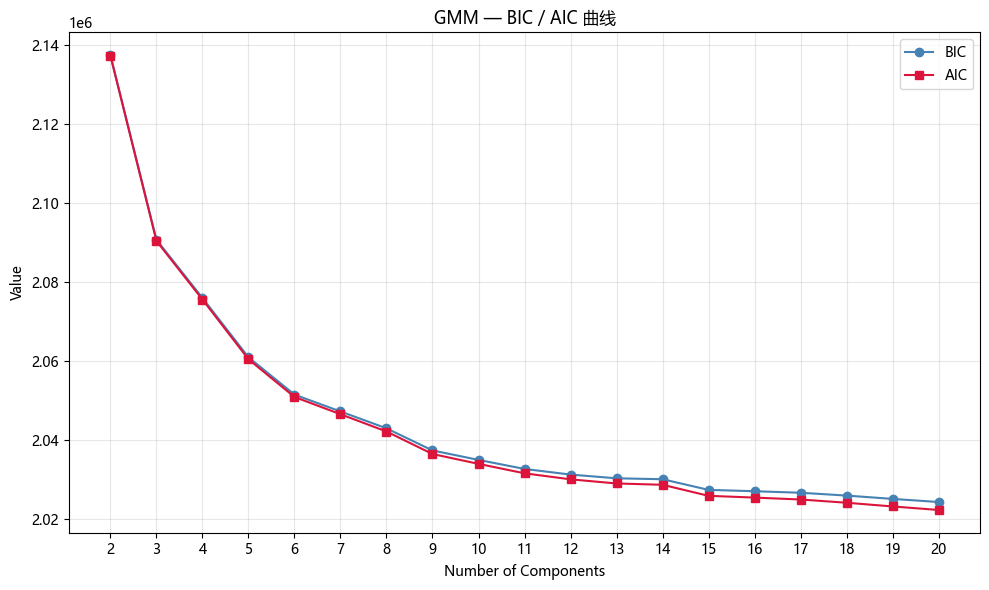

In [17]:
# ── BIC 曲线 ──
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(list(N_COMP_RANGE), bic_list, marker='o', color='steelblue', label='BIC')
ax1.plot(list(N_COMP_RANGE), aic_list, marker='s', color='crimson', label='AIC')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Value')
ax1.set_title('GMM — BIC / AIC 曲线')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(N_COMP_RANGE))   # ← 加这一行，强制显示所有整数刻度

plt.tight_layout()
plt.savefig('output/eum_gmm_bic.png', dpi=300, bbox_inches='tight')
plt.show()


In [18]:
# ═══════════════════════════════════════════════════
#  选定最终 K 值
#  ⚠ 论文方法：观察上方的 AIC 曲线，取第一个平缓平台期起始值。
#  论文推荐 K=9。请根据 AIC/BIC 曲线图人工判断后手动设置。
# ═══════════════════════════════════════════════════
# 设为 'auto' → 使用BIC最优值（算法推荐）
# 设为具体整数 → 手动指定（如 9）
SELECTED_K = 9

print(f"\n最终 GMM 参数: n_components = {SELECTED_K}")

gmm_final = GaussianMixture(n_components=SELECTED_K, random_state=42, n_init=10)
GMM_labels = gmm_final.fit_predict(X_pca_reduced)

print(f"\n聚类完成:")
print(f"  总 block 数: {len(GMM_labels):,}")
print(f"  组件数:      {SELECTED_K}")

# ── 各cluster的block数量 ──
unique_labels = sorted(set(GMM_labels))
print(f"\n{'Cluster':>8}  {'Block数':>10}  {'占比':>8}")
print("-" * 32)
for lbl in unique_labels:
    count = (GMM_labels == lbl).sum()
    pct   = count / len(GMM_labels) * 100
    print(f"  {lbl:>6d}  {count:>10,d}  {pct:>7.2f}%")


最终 GMM 参数: n_components = 9

聚类完成:
  总 block 数: 185,901
  组件数:      9

 Cluster      Block数        占比
--------------------------------
       0      27,378    14.73%
       1      35,283    18.98%
       2      50,444    27.13%
       3       9,807     5.28%
       4       2,659     1.43%
       5      12,544     6.75%
       6      11,357     6.11%
       7      21,258    11.44%
       8      15,171     8.16%


In [19]:
# ═══════════════════════════════════════════════════
#  Cluster 画像：各cluster的指标均值
# ═══════════════════════════════════════════════════

df_profile = df_clean[METRIC_COLS].copy()
df_profile['cluster'] = GMM_labels

cluster_means = df_profile.groupby('cluster')[METRIC_COLS].mean()
cluster_counts = df_profile.groupby('cluster').size()
cluster_means.insert(0, 'n_blocks', cluster_counts)

# ── 显示所有指标 ---
print(f"各 Cluster 的 {len(METRIC_COLS)} 个指标均值（用于形态解读）：\n")
print(f"{'Cluster':>8}  {'n_blocks':>10}", end='')
for col in METRIC_COLS:
    short = col[:18]
    print(f"  {short:>18}", end='')
print()
print("-" * (10 + 12 + 20 * len(METRIC_COLS)))

for lbl in sorted(cluster_means.index):
    row = cluster_means.loc[lbl]
    print(f"  {int(lbl):>6d}  {int(row['n_blocks']):>10,d}", end='')
    for col in METRIC_COLS:
        print(f"  {row[col]:>16.4f}", end='')
    print()

# ── 全局均值（参照）──
print(f"\n{'全局':>8}  {'-':>10}", end='')
global_means = df_profile[METRIC_COLS].mean()
for col in METRIC_COLS:
    print(f"  {global_means[col]:>16.4f}", end='')
print()

# ── 保存CSV ──
cluster_means.to_csv(f'output/eum_gmm_cluster_profile_k{SELECTED_K}.csv', float_format='%.4f')
print(f"\n已保存: output/eum_gmm_cluster_profile_k{SELECTED_K}.csv")

各 Cluster 的 18 个指标均值（用于形态解读）：

 Cluster    n_blocks             area_m2          mcc_radius            mcc_area             f_block                 rvh                 bcr                 avh                 hsd       avg_footprint              ba_std              bl_ave              bl_std                  dc     avg_nn_distance             rba_ave             rbl_ave                 rdc             rdb_min
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
       0      27,378        17884.6792           77.2290        19575.8854            0.9931            0.5378            0.2253            5.4748            1.5497           96.0536           65.9610     

# Section 8: 结果可视化

In [20]:
# ════════════════════════════════════════════════════════════
#  PCA 3D 散点图 — 直接使用前3个主成分作为XYZ轴
#  仅当 N_COMPONENTS >= 3 时生效（当前 N_COMPONENTS=3）
#  类似论文中基于PCA空间的聚类分布图
# ════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split

SAMPLE_SIZE_3D = 50_000

if N_COMPONENTS >= 3:
    # ── 对完整PCA结果取前3个PC做3D坐标
    X_pca_3d = X_pca[:, :3]

    if len(X_pca_3d) > SAMPLE_SIZE_3D:
        X_sample3d, _, labels_sample3d, _ = train_test_split(
            X_pca_3d, GMM_labels,
            train_size=SAMPLE_SIZE_3D,
            stratify=GMM_labels,
            random_state=42
        )
    else:
        X_sample3d, labels_sample3d = X_pca_3d, GMM_labels

    unique_labels_3d = sorted(set(labels_sample3d))

    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection='3d')
    cmap_3d = plt.cm.tab10

    for idx, lbl in enumerate(unique_labels_3d):
        mask = labels_sample3d == lbl
        cnt = mask.sum()
        ax.scatter(
            X_sample3d[mask, 0],
            X_sample3d[mask, 1],
            X_sample3d[mask, 2],
            c=[cmap_3d(idx % 10)],
            label=f'Cluster {lbl} (n={cnt})',
            alpha=0.25, s=3, edgecolors='none'
        )

    ax.set_title(f'GMM 聚类结果 — PCA 3D 空间 (K={SELECTED_K}, PC1-PC3)',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10)
    ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})', fontsize=10)
    ax.legend(markerscale=5, fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.view_init(elev=20, azim=45)
    plt.tight_layout()
    plt.savefig(f'output/eum_pca_3d_k{SELECTED_K}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"已保存: output/eum_pca_3d_k{SELECTED_K}.png")
else:
    print("N_COMPONENTS < 3, 跳过 PCA 3D 散点图（当前仅作参考）")


已保存: output/eum_pca_3d_k9.png


In [21]:
# ── UMAP 降维 + GMM聚类结果散点图 ──
from umap import UMAP
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 50_000

if len(X_pca_reduced) > SAMPLE_SIZE:
    X_sample, _, labels_sample, _ = train_test_split(
        X_pca_reduced, GMM_labels,
        train_size=SAMPLE_SIZE,
        stratify=GMM_labels,
        random_state=42
    )
else:
    X_sample, labels_sample = X_pca_reduced, GMM_labels

unique_labels = sorted(set(labels_sample))
n_clusters_found = len(unique_labels)

print(f"UMAP 降维可视化: {len(X_sample)} 点, {n_clusters_found} 个 cluster")

reducer = UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_sample)
print(f"UMAP 完成: {X_umap.shape}")

# ── 绘图 ──
fig, ax = plt.subplots(figsize=(12, 10))
cmap = plt.cm.tab10

cluster_counts_plot = pd.Series(labels_sample).value_counts().sort_index()
for idx, lbl in enumerate(unique_labels):
    mask = labels_sample == lbl
    cnt = mask.sum()
    ax.scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        c=[cmap(idx % 10)],
        label=f'Cluster {lbl} (n={cnt})',
        alpha=0.3, s=3, edgecolors='none'
    )

ax.set_title(f'GMM 聚类结果 — UMAP 降维可视化（K={SELECTED_K}）', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=5, fontsize=9, loc='best')
ax.grid(False)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'output/eum_umap_gmm_k{SELECTED_K}.png', dpi=300, bbox_inches='tight')
plt.close()

UMAP 降维可视化: 50000 点, 9 个 cluster
UMAP 完成: (50000, 2)


In [22]:
# ════════════════════════════════════════════════════════════
#  UMAP 3D 散点图 — 降维到3维作为XYZ轴
#  作为PCA 3D的非线性降维对照
# ════════════════════════════════════════════════════════════
from umap import UMAP
from sklearn.model_selection import train_test_split

SAMPLE_SIZE_UMAP_3D = 50_000

if len(X_pca_reduced) > SAMPLE_SIZE_UMAP_3D:
    X_sample_umap3d, _, labels_sample_umap3d, _ = train_test_split(
        X_pca_reduced, GMM_labels,
        train_size=SAMPLE_SIZE_UMAP_3D,
        stratify=GMM_labels,
        random_state=42
    )
else:
    X_sample_umap3d, labels_sample_umap3d = X_pca_reduced, GMM_labels

unique_labels_umap3d = sorted(set(labels_sample_umap3d))

reducer_3d = UMAP(n_neighbors=30, min_dist=0.1, n_components=3, metric='euclidean', random_state=42)
X_umap_3d = reducer_3d.fit_transform(X_sample_umap3d)
print(f"UMAP 3D 完成: {X_umap_3d.shape}")

fig = plt.figure(figsize=(14, 11))
ax = fig.add_subplot(111, projection='3d')
cmap_umap3d = plt.cm.tab10

for idx, lbl in enumerate(unique_labels_umap3d):
    mask = labels_sample_umap3d == lbl
    cnt = mask.sum()
    ax.scatter(
        X_umap_3d[mask, 0],
        X_umap_3d[mask, 1],
        X_umap_3d[mask, 2],
        c=[cmap_umap3d(idx % 10)],
        label=f'Cluster {lbl} (n={cnt})',
        alpha=0.25, s=3, edgecolors='none'
    )

ax.set_title(f'GMM 聚类结果 — UMAP 3D 空间 (K={SELECTED_K})',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('UMAP 1', fontsize=10)
ax.set_ylabel('UMAP 2', fontsize=10)
ax.set_zlabel('UMAP 3', fontsize=10)
ax.legend(markerscale=5, fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.savefig(f'output/eum_umap_3d_k{SELECTED_K}.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"已保存: output/eum_umap_3d_k{SELECTED_K}.png")


UMAP 3D 完成: (50000, 3)
已保存: output/eum_umap_3d_k9.png


In [23]:
# ═══════════════════════════════════════════════════
#  选择各cluster典型block（最靠近质心）
#  复用 lod1_clustering.ipynb 的 Section 5.2 逻辑
# ═══════════════════════════════════════════════════
from scipy.spatial.distance import cdist

N_PER_CLUSTER = 5

# ── GMM 质心（在PCA空间）──
centroids = gmm_final.means_

selected_blocks = []
for lbl in unique_labels:
    mask = GMM_labels == lbl
    X_cluster = X_pca_reduced[mask]
    idx_cluster = np.where(mask)[0]
    centroid = centroids[lbl].reshape(1, -1)

    dists = cdist(X_cluster, centroid, metric='euclidean').flatten()
    nearest_idx = np.argsort(dists)[:N_PER_CLUSTER]

    for ni in nearest_idx:
        global_idx = idx_cluster[ni]
        selected_blocks.append({
            'cluster':  int(lbl),
            'block_id': block_ids[global_idx],
            'city':     cities[global_idx],
            'distance': dists[ni]
        })

df_selected = pd.DataFrame(selected_blocks)
print(f"从 {n_clusters_found} 个 cluster 中各选 {N_PER_CLUSTER} 个典型 block（共 {len(df_selected)} 个）\n")
display(df_selected)

从 9 个 cluster 中各选 5 个典型 block（共 45 个）



,cluster,block_id,city,distance
0,0,US_CH_012336,Chicago,0.027216
1,0,US_CH_018695,Chicago,0.032156
2,0,US_CH_010748,Chicago,0.034102
3,0,US_CH_000178,Chicago,0.034342
4,0,US_CH_002135,Chicago,0.039857
5,1,CA_TO_005778,Toronto,0.042232
6,1,JP_OS_009348,Osaka,0.054699
7,1,JP_TK_054405,Tokyo,0.068720
8,1,US_WA_001487,Washington D.C.,0.091898
9,1,CA_TO_002726,Toronto,0.099915


In [24]:
# ═══════════════════════════════════════════════════
#  查询典型block的几何数据（block边界 + 建筑footprint）
# ═══════════════════════════════════════════════════

# ── 先查询城市名映射表 ──
city_map_rows = utils_z.run_sql(
    "SELECT city, city_query FROM summary.city_name_map;",
    fetch=True, conn=conn
)
CITY_QUERY_MAP = {row[0]: row[1] for row in city_map_rows}

city_groups = df_selected.groupby('city')
block_geom_data = {}

for city_display, group in city_groups:
    city_query = CITY_QUERY_MAP.get(city_display, city_display)
    block_ids_list = group['block_id'].tolist()
    placeholders = ", ".join([f"'{bid}'" for bid in block_ids_list])

    block_table = f"block.{city_query}_blocks"
    bld_table = f"lod1.{city_query}_buildings_lod1"

    # ── block geom ──
    rows_block = utils_z.run_sql(f"""
        SELECT block_id, ST_AsText(geom) FROM {block_table}
        WHERE block_id IN ({placeholders});
    """, fetch=True, conn=conn)
    for bid, wkt in rows_block:
        block_geom_data[str(bid)] = {'geom_wkt': wkt, 'footprints': []}

    # ── building footprints ──
    rows_fp = utils_z.run_sql(f"""
        SELECT block_id, ST_AsText(geom_2d)
        FROM {bld_table}
        WHERE block_id IN ({placeholders})
          AND geom_2d IS NOT NULL AND ST_IsValid(geom_2d);
    """, fetch=True, conn=conn)
    for bid, wkt in rows_fp:
        if str(bid) in block_geom_data:
            block_geom_data[str(bid)]['footprints'].append(wkt)

print(f"查询完成: {len(block_geom_data)} blocks, "
      f"{sum(len(v['footprints']) for v in block_geom_data.values())} footprints")

查询完成: 45 blocks, 1186 footprints


In [25]:
# ═══════════════════════════════════════════════════
#  2D 拼图：block边界 + 建筑footprint
# ═══════════════════════════════════════════════════
from shapely.wkt import loads as wkt_loads

n_rows = n_clusters_found
n_cols = N_PER_CLUSTER
DISPLAY_RANGE = 1.0
PADDING = 0.1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
fig.suptitle('各 Cluster 典型 Block — 2D 平面图（EUM-GMM）', fontsize=14, y=1.01)

if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes

for _, row in df_selected.iterrows():
    lbl = row['cluster']
    bid = row['block_id']
    city = row['city']

    # 计算在拼图中的位置
    r_idx = int(lbl)
    subset = df_selected[df_selected['cluster'] == lbl].reset_index(drop=True)
    c_idx = int(subset[subset['block_id'] == bid].index[0])

    ax = axes[r_idx, c_idx] if n_rows > 1 else axes[c_idx]

    geom_entry = block_geom_data.get(bid)
    if geom_entry is None:
        ax.text(0.02, 0.98, f'C{lbl} | {bid[:8]}... | {city}', fontsize=7,
                transform=ax.transAxes, va='top')
        ax.set_xticks([]); ax.set_yticks([])
        continue

    block_poly = wkt_loads(geom_entry['geom_wkt'])
    if block_poly.is_empty:
        continue

    # 局部投影
    minx, miny, maxx, maxy = block_poly.bounds
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2
    m_per_deg_lon = math.cos(math.radians(cy)) * 111320
    m_per_deg_lat = 111320

    def to_local(xs, ys):
        return ([(x - cx) * m_per_deg_lon for x in xs],
                [(y - cy) * m_per_deg_lat for y in ys])

    bx_raw, by_raw = block_poly.exterior.xy
    bx_loc, by_loc = to_local(bx_raw, by_raw)
    half_span = max(max(bx_loc) - min(bx_loc), max(by_loc) - min(by_loc)) / 2 or 1.0

    def norm(vals):
        return [v / half_span for v in vals]

    ax.plot(norm(bx_loc), norm(by_loc), color='#333333', linewidth=1.5, zorder=2)

    for fp_wkt in geom_entry['footprints']:
        try:
            fp_poly = wkt_loads(fp_wkt)
            if fp_poly.is_empty:
                continue
            fx, fy = fp_poly.exterior.xy
            fx_loc, fy_loc = to_local(fx, fy)
            ax.fill(norm(fx_loc), norm(fy_loc),
                    color='#4A72B5', alpha=0.5, edgecolor='#2C3E6B', linewidth=0.5, zorder=3)
        except Exception:
            pass

    lim = DISPLAY_RANGE + PADDING
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    ax.text(0.02, 0.98, f'C{lbl} | {bid} | {city}', fontsize=7,
            transform=ax.transAxes, va='top')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_color('#cccccc')

plt.tight_layout()
plt.savefig(f'output/eum_blocks_2d_k{SELECTED_K}.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"已保存: output/eum_blocks_2d_k{SELECTED_K}.png")

已保存: output/eum_blocks_2d_k9.png


In [26]:
# ═══════════════════════════════════════════════════
#  3D 轴测拼图（pyvista off-screen 模式）
# ═══════════════════════════════════════════════════
import pyvista as pv

def polygon_to_mesh(coords, cx, cy, base_z,
                    m_per_deg_lon, m_per_deg_lat, z_scale=1.0):
    pts = np.array([
        [(c[0] - cx) * m_per_deg_lon,
         (c[1] - cy) * m_per_deg_lat,
         ((c[2] if len(c) > 2 else base_z) - base_z) * z_scale]
        for c in coords[:-1]
    ])
    if len(pts) < 3:
        return None
    faces = np.array([len(pts)] + list(range(len(pts))))
    return pv.PolyData(pts, faces).triangulate()

# ── 查询 building surfaces ──
surface_data = {}
for city_display, group in city_groups:
    city_query = CITY_QUERY_MAP.get(city_display, city_display)
    block_ids_list = group['block_id'].tolist()
    placeholders = ", ".join([f"'{bid}'" for bid in block_ids_list])

    bld_table = f"lod1.{city_query}_buildings_lod1"
    surf_table = f"lod1.{city_query}_building_surfaces_lod1"

    rows_surf = utils_z.run_sql(f"""
        SELECT b.block_id, s.surface_type, ST_AsText(s.geom_3d)
        FROM {surf_table} s
        JOIN {bld_table} b ON s.building_id = b.building_id
        WHERE b.block_id IN ({placeholders});
    """, fetch=True, conn=conn)

    for bid, stype, wkt in rows_surf:
        key = str(bid)
        if key not in surface_data:
            surface_data[key] = []
        surface_data[key].append((stype, wkt))

print(f"3D surface 查询完成: {len(surface_data)} blocks")

def build_block_mesh_3d(bid, geom_entry, surfaces):
    block_poly = wkt_loads(geom_entry['geom_wkt'])
    if block_poly.is_empty:
        return None, None

    minx, miny, maxx, maxy = block_poly.bounds
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2
    m_per_deg_lon = math.cos(math.radians(cy)) * 111320
    m_per_deg_lat = 111320

    base_z = float('inf')
    for stype, wkt in surfaces:
        try:
            poly = wkt_loads(wkt)
            for c in poly.exterior.coords:
                if len(c) > 2:
                    base_z = min(base_z, c[2])
        except Exception:
            pass
    if base_z == float('inf'):
        base_z = 0.0

    block_mesh = None
    try:
        coords = list(block_poly.exterior.coords)
        block_mesh = polygon_to_mesh(coords, cx, cy, base_z,
                                     m_per_deg_lon, m_per_deg_lat)
    except Exception:
        pass

    meshes = []
    for stype, wkt in surfaces:
        try:
            poly = wkt_loads(wkt)
            coords = list(poly.exterior.coords)
            if len(coords) < 4:
                continue
            mesh = polygon_to_mesh(coords, cx, cy, base_z,
                                   m_per_deg_lon, m_per_deg_lat, 1.0)
            if mesh is None or mesh.n_points == 0 or mesh.n_cells == 0:
                continue
            if stype == "RoofSurface":
                color = (241, 164, 147)
            elif stype == "WallSurface":
                color = (248, 239, 234)
            else:
                color = (193, 164, 160)
            mesh['color'] = np.tile(color, (mesh.n_cells, 1))
            meshes.append(mesh)
        except Exception:
            pass

    building_mesh = None
    if meshes:
        building_mesh = meshes[0].merge(meshes[1:]) if len(meshes) > 1 else meshes[0]
    return block_mesh, building_mesh

# ── 渲染 ──
plotter = pv.Plotter(shape=(n_rows, n_cols), window_size=[3000, 2500], off_screen=True)
plotter.set_background('#FFFFFF')

for _, row in df_selected.iterrows():
    lbl = row['cluster']
    bid = row['block_id']

    r_idx = int(lbl)
    subset = df_selected[df_selected['cluster'] == lbl].reset_index(drop=True)
    c_idx = int(subset[subset['block_id'] == bid].index[0])

    plotter.subplot(r_idx, c_idx)

    geom_entry = block_geom_data.get(bid)
    surf_list = surface_data.get(bid, [])
    if geom_entry is None:
        continue

    block_mesh, building_mesh = build_block_mesh_3d(bid, geom_entry, surf_list)

    if building_mesh is not None:
        plotter.add_mesh(building_mesh, scalars='color', rgb=True, show_edges=False)
        edges = building_mesh.extract_feature_edges(
            boundary_edges=True, feature_edges=True, feature_angle=30, manifold_edges=False)
        plotter.add_mesh(edges, color='#383838', line_width=0.8)

    if block_mesh is not None:
        plotter.add_mesh(block_mesh, color='#e0d0c8', opacity=0.3, show_edges=False)
        block_edges = block_mesh.extract_feature_edges(
            boundary_edges=True, feature_edges=False, manifold_edges=False)
        plotter.add_mesh(block_edges, color='#1F1F1F', line_width=2)

    plotter.add_text(f'C{lbl}', font_size=8, position='upper_left')
    plotter.camera_position = 'iso'
    plotter.camera.zoom(1.5)

plotter.screenshot(f'output/eum_blocks_3d_k{SELECTED_K}.png')
print(f"已保存: output/eum_blocks_3d_k{SELECTED_K}.png")

3D surface 查询完成: 45 blocks
已保存: output/eum_blocks_3d_k9.png


# 附录：EUM-GMM 与原始聚类方法对比

可选分析：将EUM-GMM的聚类标签与原始K-Means/DBSCAN的结果进行对比，\
观察EUM归一化后的聚类分布差异。

In [ ]:
# ── 对比EUM-GMM vs 原始K-Means/DBSCAN ──
# （需要先从原聚类notebook加载标签，或直接运行一次原聚类流程的简化版）
print("如需对比，请在此处加载原 lod1_clustering.ipynb 的聚类标签，")
print("然后通过交叉表分析两个聚类结果的重叠情况。")
print("\n示例：")
print("  pd.crosstab(original_labels, GMM_labels, normalize='index')")

# 临时处理
## 检查block id索引

In [7]:
# ──────────────────────────────────────────────────
#  临时检查：建筑表 block_id 索引
#  检查所有城市的建筑表是否已给 block_id 建索引；没有则创建
# ──────────────────────────────────────────────────

for city in lod1_cities:
    bld_table = f"lod1.{city}_buildings_lod1"
    idx_name = f"{city}_buildings_lod1_block_id_idx"

    try:
        rows = utils_z.run_sql(f"""
            SELECT indexname
            FROM pg_indexes
            WHERE schemaname = 'lod1'
              AND tablename = '{city}_buildings_lod1'
              AND indexdef ILIKE '%(block_id)%';
        """, fetch=True, conn=conn)

        if rows:
            names = ', '.join(r[0] for r in rows)
            print(f"  [{city}] 已有 block_id 索引: {names}")
            continue

        utils_z.run_sql(f"""
            CREATE INDEX IF NOT EXISTS {idx_name}
            ON {bld_table} (block_id);
        """, conn=conn)
        print(f"  [{city}] 已创建 block_id 索引: {idx_name}")

    except Exception as e:
        conn.rollback()
        print(f"  [{city}] 检查/创建失败: {e}")


## 修正：将 mcc_radius / mcc_area 从度转为米，并重算依赖指标

前面 Sec1 的 MCC 计算是在 EPSG:4326 坐标系下直接产出度单位的半径和面积，
导致后续 f_block / rba_ave / rbl_ave / rdc / rdb_min 全部爆炸。
\
此处用 SQL 批量修正已有数据，再重算 ff_block + 全部四个归一化指标。

In [14]:
# ──────────────────────────────────────────────────────
#  修复 A：修正 mcc_radius 和 mcc_area 的单位（度→米）
#  借用 mcc_center 的纬度来计算局部米/度比例
# ──────────────────────────────────────────────────────

print("修正前（旧：度制）:")
old_stats = utils_z.run_sql(
    "SELECT COUNT(*), MIN(mcc_radius), AVG(mcc_radius), MAX(mcc_radius) FROM summary.lod1_valid_eum_blocks WHERE mcc_radius IS NOT NULL;",
    fetch=True, conn=conn
)[0]
print(f"  count={old_stats[0]} | min={old_stats[1]:.6f} | mean={old_stats[2]:.6f} | max={old_stats[3]:.6f}")

utils_z.run_sql("""
    UPDATE summary.lod1_valid_eum_blocks
    SET
        mcc_radius = mcc_radius * 111320 * COS(RADIANS(ST_Y(mcc_center))),
        mcc_area   = PI() * (mcc_radius * 111320 * COS(RADIANS(ST_Y(mcc_center)))) ^ 2
    WHERE mcc_radius IS NOT NULL
      AND mcc_center IS NOT NULL;
""", conn=conn)
conn.commit()

print("\n修正后（新：米制）:")
new_stats = utils_z.run_sql(
    "SELECT COUNT(*), MIN(mcc_radius), AVG(mcc_radius), MAX(mcc_radius) FROM summary.lod1_valid_eum_blocks WHERE mcc_radius IS NOT NULL;",
    fetch=True, conn=conn
)[0]
print(f"  count={new_stats[0]} | min={new_stats[1]:.2f} | mean={new_stats[2]:.2f} | max={new_stats[3]:.2f}")
print("\nmcc_radius 与 mcc_area 单位修正完成（度→米）")


In [15]:
# ──────────────────────────────────────────────────────
#  修复 B：重新计算依赖 mcc 的指标
#  • f_block     = area_m2 / mcc_area
#  • rba_ave     = avg_footprint / mcc_area
#  • rbl_ave     = bl_ave / (2π × mcc_radius)
#  • rdc         = dc / mcc_radius
#  • rdb_min     = avg_nn_distance / mcc_radius
# ──────────────────────────────────────────────────────

# ── f_block（已在 sec2c 中整表更新，但确保用修整后的 mcc_area 执行）──
utils_z.run_sql("""
    UPDATE summary.lod1_valid_eum_blocks
    SET f_block = CASE
        WHEN mcc_area IS NOT NULL AND mcc_area > 0
        THEN area_m2 / mcc_area
        ELSE NULL
    END;
""", conn=conn)
print("f_block 已重算")

# ── 归一化指标 rba_ave / rbl_ave / rdc / rdb_min ──
utils_z.run_sql("""
    UPDATE summary.lod1_valid_eum_blocks
    SET
        rba_ave = CASE
            WHEN mcc_area IS NOT NULL AND mcc_area > 0
            THEN avg_footprint / mcc_area
            ELSE NULL
        END,
        rbl_ave = CASE
            WHEN mcc_radius IS NOT NULL AND mcc_radius > 0
            THEN bl_ave / (2 * PI() * mcc_radius)
            ELSE NULL
        END,
        rdc = CASE
            WHEN mcc_radius IS NOT NULL AND mcc_radius > 0
            THEN dc / mcc_radius
            ELSE NULL
        END,
        rdb_min = CASE
            WHEN mcc_radius IS NOT NULL AND mcc_radius > 0
            THEN avg_nn_distance / mcc_radius
            ELSE NULL
        END;
""", conn=conn)
print("rba_ave / rbl_ave / rdc / rdb_min 已重算")

# ── 验证 ──
final_counts = utils_z.run_sql("""
    SELECT
        COUNT(*) AS total,
        COUNT(mcc_radius),
        COUNT(f_block),
        COUNT(rba_ave),
        COUNT(rbl_ave),
        COUNT(rdc),
        COUNT(rdb_min)
    FROM summary.lod1_valid_eum_blocks;
""", fetch=True, conn=conn)[0]
print(f"\n修正后验证:")
print(f"  mcc_radius:     {final_counts[1]}/{final_counts[0]}")
print(f"  f_block:        {final_counts[2]}/{final_counts[0]}")
print(f"  rba_ave:        {final_counts[3]}/{final_counts[0]}")
print(f"  rbl_ave:        {final_counts[4]}/{final_counts[0]}")
print(f"  rdc:            {final_counts[5]}/{final_counts[0]}")
print(f"  rdb_min:        {final_counts[6]}/{final_counts[0]}")
